### EX: Classifying Sonar Returns (Linear vs. Neural Networks)

In this exercise, we will tackle a highly non-linear classification problem by evaluating simulated sonar returns (differentiating subsurface mines from harmless rocks). We will compare a baseline linear model against a deep feedforward neural network built using **TensorFlow/Keras**.

Crucially, we will apply **Feature Scaling** to our data. Neural networks require inputs to be on a similar scale (e.g., a mean of 0 and a variance of 1) so their optimization algorithms can successfully converge on complex boundaries without getting stuck.

#### Steps Performed

* **Generate Data:** Create a non-linear, interlocking dataset representing complex sonar signatures (a `make_moons` dataset where target and clutter signatures overlap).

* **Split Data:** Divide the sonar data into training and testing sets.

* **Scale Data:** Apply a `StandardScaler` so the features are normalized.

* **Train Models:** Train a baseline linear model (Logistic Regression) and a multi-layer feedforward Neural Network (`Sequential`) containing *two* hidden `Dense` layers with 10 neurons each, using a ReLU activation function.

* **Visualize Boundaries:** Generate a meshgrid to plot the test data points overlaying the decision boundaries for both models side-by-side.

In [ ]:
#Only run this cell after selecting your kernel
!python.exe -m pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas tensorflow

--- Keras Model Architecture ---


c:\Users\codeh\471Book\jnb_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

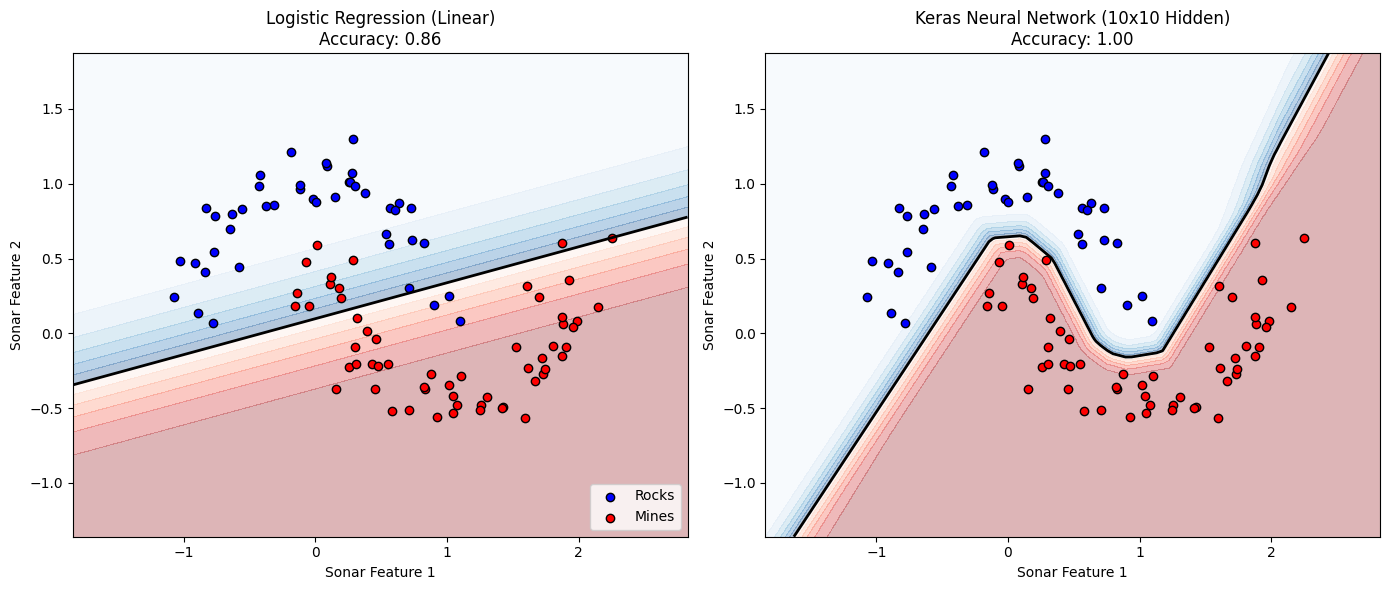

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Keras Imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Generate Non-Linear Sonar Data (Interlocking signatures)
# 0: Harmless Rocks (Clutter), 1: Subsurface Mines (Target)
X_sonar, y_sonar = make_moons(n_samples=500, noise=0.15, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_sonar, y_sonar, test_size=0.2, random_state=42)

# 2. Scale the Data (Crucial for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train the Baseline Linear Model (Logistic Regression)
log_reg = LogisticRegression().fit(X_train_scaled, y_train)

# 4. Build and Train the Keras Neural Network
print("--- Keras Model Architecture ---")
keras_model = Sequential([
    # Input layer & First Hidden Layer (10 neurons, ReLU)
    Dense(10, activation='relu', input_shape=(2,)),
    # Second Hidden Layer (10 neurons, ReLU)
    Dense(10, activation='relu'),
    # Output Layer (1 neuron, Sigmoid for binary probability)
    Dense(1, activation='sigmoid')
])

# Print the model output/summary
keras_model.summary()

# Compile the model
keras_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model (epochs=200, verbose=0 hides the epoch-by-epoch training text)
keras_model.fit(X_train_scaled, y_train, epochs=200, batch_size=32, verbose=0)

# 5. Prepare the Meshgrid for Plotting Decision Boundaries
# Note: We build the meshgrid on the original scale for intuitive axis labels
xx, yy = np.meshgrid(np.linspace(X_sonar[:,0].min()-0.5, X_sonar[:,0].max()+0.5, 100),
                     np.linspace(X_sonar[:,1].min()-0.5, X_sonar[:,1].max()+0.5, 100))

# We must scale the meshgrid points before predicting
mesh_points = np.c_[xx.ravel(), yy.ravel()]
mesh_points_scaled = scaler.transform(mesh_points)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
titles = ['Logistic Regression (Linear)', 'Keras Neural Network (10x10 Hidden)']

# 6. Plot Logistic Regression
Z_log = log_reg.predict_proba(mesh_points_scaled)[:, 1] - 0.5
Z_log = Z_log.reshape(xx.shape)
axes[0].contourf(xx, yy, Z_log, levels=np.linspace(Z_log.min(), 0, 7), cmap='Blues', alpha=0.3) 
axes[0].contourf(xx, yy, Z_log, levels=np.linspace(0, Z_log.max(), 7), cmap='Reds', alpha=0.3) 
axes[0].contour(xx, yy, Z_log, levels=[0], linewidths=2, colors='black')

# 7. Plot Keras Neural Network
# Keras predict() returns an array of shape (n_samples, 1), so we flatten it
Z_keras = keras_model.predict(mesh_points_scaled, verbose=0).flatten() - 0.5
Z_keras = Z_keras.reshape(xx.shape)
axes[1].contourf(xx, yy, Z_keras, levels=np.linspace(Z_keras.min(), 0, 7), cmap='Blues', alpha=0.3) 
axes[1].contourf(xx, yy, Z_keras, levels=np.linspace(0, Z_keras.max(), 7), cmap='Reds', alpha=0.3) 
axes[1].contour(xx, yy, Z_keras, levels=[0], linewidths=2, colors='black')

# 8. Scatter test data & set formatting
for i, ax in enumerate(axes):
    model_preds = log_reg.predict(X_test_scaled) if i == 0 else (keras_model.predict(X_test_scaled, verbose=0).flatten() > 0.5).astype(int)
    acc = accuracy_score(y_test, model_preds)
    
    ax.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], color='blue', label='Rocks', edgecolors='k')
    ax.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], color='red', label='Mines', edgecolors='k')
    
    ax.set_title(f"{titles[i]}\nAccuracy: {acc:.2f}")
    ax.set_xlabel('Sonar Feature 1')
    ax.set_ylabel('Sonar Feature 2')

axes[0].legend(loc='lower right')
plt.tight_layout()
plt.show()



> * **Plot 1 (Logistic Regression):** A straight black diagonal line attempts to cut through the interlocking red and blue crescents. Because the data is curved, the straight line fails to cleanly separate the groups, misclassifying a large chunk of red points in the blue zone and vice versa. Accuracy is roughly **0.86**.
>
> * **Plot 2 (Neural Network):** The black decision boundary is highly curved, snaking beautifully between the interlocking crescent shapes. Almost all blue points are bounded within the blue contour region, and red points in the red contour region. Accuracy is roughly **0.99**.

#### Interpreting the Results

The interlocking data simulates a complex operational scenario where the acoustic signatures of subsurface mines (red dots) heavily overlap with the signatures of harmless rocks (blue dots). Look at the two plots to understand the limitations of linear models and the power of feedforward architectures:

1. **Logistic Regression (Fails):** This algorithm is constrained to a single, linear weighted sum. It tries to draw a straight line through the data. Because you cannot separate two interlocking crescents with a straight line, the model is forced to compromise, leaving a significant number of targets misclassified.
2. **Neural Network (Succeeds):** The neural network utilizes two hidden layers with 10 artificial neurons each and a **ReLU activation function**. During forward propagation, the ReLU function introduces non-linearity. Rather than drawing one straight line, the network effectively learns multiple piecewise linear boundaries, folding and combining them to create a highly complex, custom-fitted curve that separates the overlapping classes.

**The Tactical Takeaway:** Unlike strict statistical algorithms that might require careful feature engineering or assumption mapping, neural networks automatically learn non-linear representations of raw data. However, as demonstrated by the need to apply `StandardScaler`, they require proper **feature scaling** (standardization) and sufficient architectural depth to successfully converge on those complex boundaries.